In [1]:
import os
import gymnasium as gym
import numpy as np
import seaborn as sns
import torch
import torch as th
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.vec_env import SubprocVecEnv
from torch.distributions import Categorical
from torch.nn import functional as F
import agent_encoder
import common_layers
import embedding
import fourier_embedding
from models import EgoAttentionExtractor
# 切换工作目录到COMPASS项目主目录
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

d:\Anaconda\envs\graphflow\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
# import gymnasium as gym
# import compass_env
# from compass_env.envs.compass_parallel_env import CompassParallelEnv

# env = gym.make("compass-highway-v2", render_mode="human")
# env.reset()
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv
import compass_env

def make_env(rank: int, base_port: int = 12000, seed: int = 0):
    def _init():
        cfg = {
            "simulation": {
                "traci_port": base_port + rank,
                "traci_label": f"compass-r{rank}",
            },
            "case_num": -1,  # 或固定一个 case 便于复现
        }
        env = gym.make("compass-highway-v2", config=cfg, render_mode=None, verbose=False)
        env.reset(seed=seed + rank)
        return env
    return _init


n_envs = 4
env = DummyVecEnv([make_env(i) for i in range(n_envs)])

obs = env.reset()
print("reset ok")
# obs 是 vectorized 结构：Dict[str, np.ndarray]
print({k: v.shape for k, v in obs.items()})



找到 168 个.state.xml.gz文件
找到 168 个.state.xml.gz文件
找到 168 个.state.xml.gz文件
找到 168 个.state.xml.gz文件
reset ok
{'ego': (4, 53), 'veh': (4, 15, 20, 25)}


In [3]:
obs['ego'].shape, obs['veh'].shape

((4, 53), (4, 15, 20, 25))

In [4]:
obs_th = {'ego': th.from_numpy(obs['ego']), 'veh': th.from_numpy(obs['veh'])}
print(obs_th['ego'].shape, obs_th['veh'].shape)
# 检查obs_th中是否有数值异常


torch.Size([4, 53]) torch.Size([4, 15, 20, 25])


In [5]:
from compass_env.utils import vis_matrix
network_kwargs = dict(
    embedding_layer_kwargs = {"state_channel": 51,
                                "history_channel":24,
                                "dim": 128,
                                "hist_steps":20,
                                "state_attn_encoder":True,
                                "presence_index": env.envs[0].unwrapped.nh_obs.veh_feat_var["presence"],
                                "v_type_index": env.envs[0].unwrapped.nh_obs.veh_feat_var["vtype"]},
    attention_layer_kwargs = {"feature_dim": 128, "heads": 4},
)
encoder = agent_encoder.AgentEncoder()
extractor = EgoAttentionExtractor(env.observation_space,**network_kwargs)

In [6]:
x_feat = extractor(obs_th)
attn_mat = extractor.get_attention_matrix(obs_th)

torch.Size([4, 4, 1, 16])


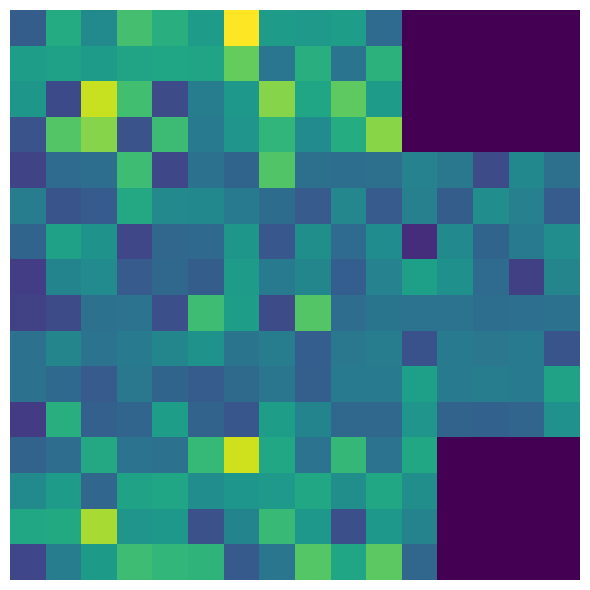

In [ ]:
print(attn_mat.shape)
vis_matrix(attn_mat.detach().numpy().reshape(16,16)) # [B, H, 1, 1+V]

In [8]:
x_ego, x_agent, valid_agent_mask = encoder(obs_th)

torch.Size([4, 128])


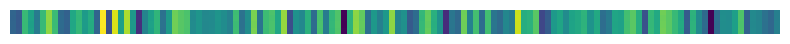

In [9]:
print(x_ego.shape)
vis_matrix(x_ego.detach())

torch.Size([4, 15, 128])


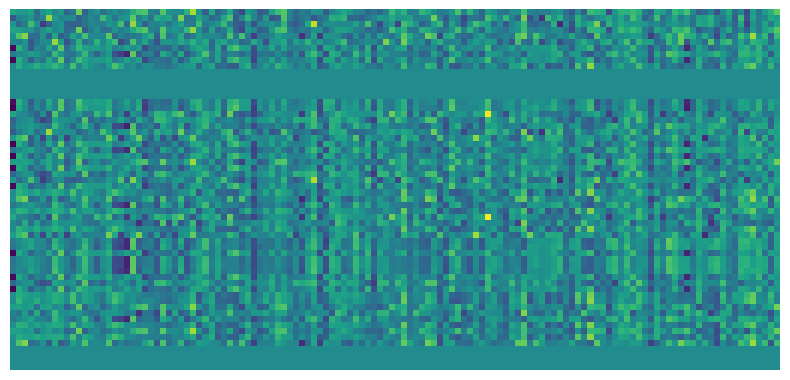

In [10]:
print(x_agent.shape)
vis_matrix(x_agent.detach().numpy().reshape(4*15, 128))

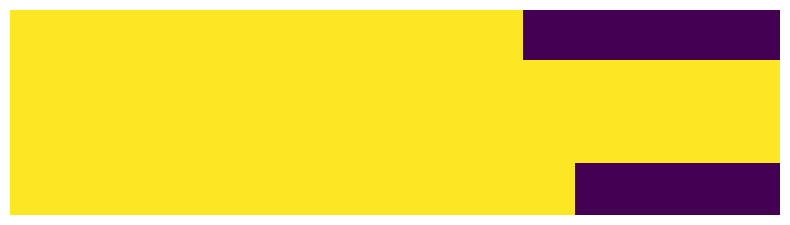

In [11]:
vis_matrix(valid_agent_mask.reshape(4,15).detach().numpy())
